# Simulation-based Optimization

Thus far in the course, we've focused on optimization problems in which the objective and constraints are explicit functions of the design variables.
Often, the objective and constraint values in engineering design optimization problems are functions of a underlying simulation.
In this section, we examine the consequences of this, focusing on how to apply optimization algorithms to these types of problems.

## Background example: Lifting line analysis of a wing

In this notebook, we'll start to look at simulation-based design optimization. For the purposes of this section, we'll look at some simple aerodynamic optimization problems using lifting-line theory.

A good review of lifting line theory can be found here: 

https://en.wikipedia.org/wiki/Lifting-line_theory

In lifting line theory, the bound circulation can be written as a function of the span-wise coordinate $y$ as follows:

\begin{equation*}
\Gamma(\theta) = 2 b V_{\infty} \sum_{n=1}^{\infty} u_{n} sin(n\theta)
\end{equation*}

here the span-wise coordinate, $y$ is computed from $\theta$ using $y = \frac{b}{2} \cos(\theta)$. The variable $b$ is the wing span and $V_{\infty}$ is the free-stream velocity.

The Fourier coefficients $u_{n}$ are unknowns. For computations, the coefficients are truncated for $n = 1, \ldots, N$, so that we solve for $u_{1}, u_{2}, \ldots, u_{N}$.

The following system of $N$ equations can be obtained to find these coefficients:

$$\begin{bmatrix} a_{11} & a_{12} & \ldots & a_{1N} \\ a_{21} & a_{22} & \ldots & a_{2N} \\ \vdots & \vdots & \ddots & \vdots \\ a_{N1} & a_{N2} & \ldots & a_{NN} \\ \end{bmatrix} \begin{bmatrix} u_{1} \\ u_{2} \\ \vdots \\ u_{N} \\ \end{bmatrix} = \begin{bmatrix} b_{1} \\ b_{2} \\ \vdots \\ b_{N} \\ \end{bmatrix}$$

where the entries $a_{nm}$ and $b_{n}$ are given by

\begin{equation*}
a_{mn} = \sin(n\theta_{m})\sin(\theta_{m}) + c_{l,\alpha} \frac{c(\theta_{m})}{4b} \sin(\theta_{m})
\end{equation*}

\begin{equation*}
b_{m} = \sin(\theta_{m})\frac{c(\theta_{m})}{4b} c_{l,\alpha} (\alpha_{\infty} + x_{m})
\end{equation*}

Here $c(\theta)$ is the wing chord, $c_{l,\alpha}$ is the sectional lift curve slope and $\alpha_{\infty}$ is the angle of attack. The design variables $x_{m}$ is the twist of the wing at the $m-th$ collocation point.

### Output functions of interest

We're not interested in determining just the coefficients $u_{n}$, we want to know what the lift, drag, and perhaps root bending moment are on the wing as a function of the design variables.

The coefficient of lift produced by the wing is

\begin{equation*}
C_{L} = \pi AR u_{1}.
\end{equation*}

The coefficient of drag produced by the wing is

\begin{equation*}
C_{D} = \pi AR \sum_{n=1}^{N} n u_{n}^{2}.
\end{equation*}

The root bending moment coefficient defined is defined as

\begin{equation*}
C_{b} = \frac{M_{b}}{\frac{1}{2}\rho V_{\infty}^2 S b} = AR \sum_{n=1}^{N} c_{n} u_{n},
\end{equation*}

where $c_{n}$ are given as follows $c_{2} = 0$ and all other values are given by

\begin{equation*}
c_{n} = \frac{(2\sin(n\pi/2) - \sin(\pi n))}{4 - n^2}.
\end{equation*}

### Optimization problem formulations

Now we want to solve an optimization problem. We want to design the wing so that it has minimum $C_{D}$ while meeting a requirement for lift $C_{L} = C_{L,\text{target}}$. This constrained optimization problem can be expressed as:

\begin{equation*}
\begin{aligned}
\min_{x} \qquad & C_{D} \\
\text{such that} \qquad & C_{L} = C_{L,\text{target}} \\
\end{aligned}
\end{equation*}

This will give the classical lifting line result that the minimum induced drag is produced by an ellipitical lift distribution.

However, this results in a lift distribution in which the wing tip is subject to higher loads, which can result in a heavier structure. Therefore, we can consider an additional constraint where we seek to reduce the bending moment at the root of the wing by limiting $C_{b} \le C_{b,\text{target}}$.

\begin{equation*}
\begin{aligned}
\min_{x} \qquad & C_{D} \\
\text{such that} \qquad & C_{L} = C_{L,\text{target}} \\
\qquad \text{and} \qquad & C_{b} \le C_{b,\text{target}} \\
\end{aligned}
\end{equation*}

This will produce a more triangular lift distribution that shifts lift inboard.

### Computational cost

These problems are solved with ``scipy.minimize.`` Note that as $N$ increases, the computational cost grows rapidly. That's because the lifting line theory code is invoked $N+1$ times to compute the gradient of the objective and constraints. This computational cost adds up quickly as the number of design variables increase. In addition, a larger design problem takes longer to solve, making these larger design problems even more computationally expensive.

To address this issue, we need a fast way to compute the gradient!

message:        Optimization terminated successfully
function evals: 481
iterations:     15
message:        Optimization terminated successfully
function evals: 480
iterations:     15


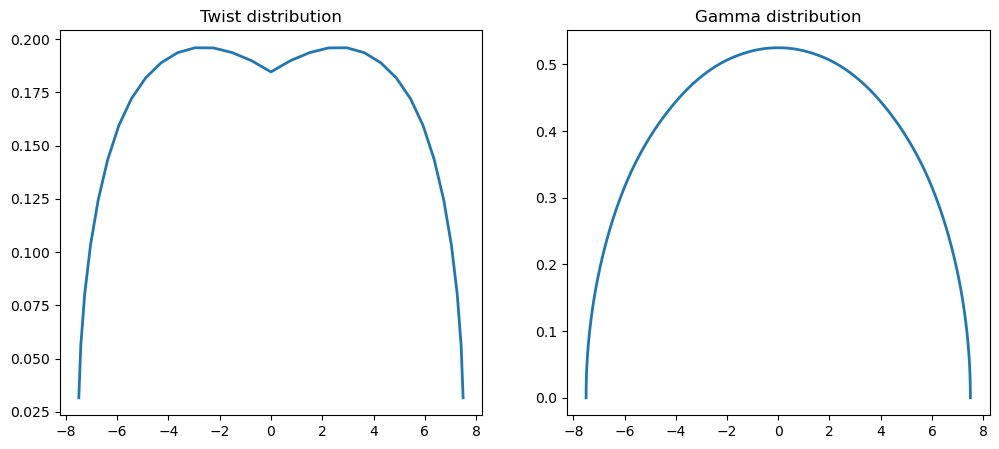

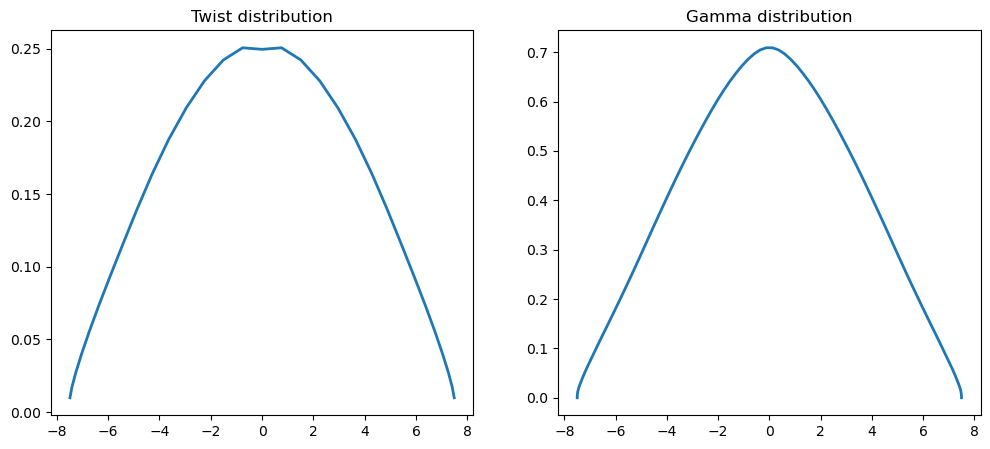

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pylab as plt
%matplotlib inline

class LiftingLine:
    def __init__(self, N, b, c_root, c_tip,
                 cl_alpha=2*np.pi, CL_target=1.0, Cb_target=1.0):
        """
        Instantiate the lifting line theory class.
        
        This creates the data needed to perform the lifting line theory
        analysis for a simple, tapered, unswept wing with a fixed lift
        and optionally specified wing root bending moment.
        
        Args:
            N (int): The number of Fourier coefficients
            b (float): The wing span
            c_root (float): The root chord
            c_tip (float): The tip chord
            cl_alpha (float): The lift curve slope of the airfoil
            CL_target (float): The target coefficient of lift
            Cb_target (float): The target bending moment coefficient
        """
        
        self.N = N
        
        self.alpha = 0.0
        self.b = b
        self.S = 0.5*self.b*(c_root + c_tip)
        self.cl_alpha = cl_alpha
        self.CL_target = CL_target
        self.Cb_target = Cb_target
        
        # Set the theta locations and compute their corresponding y-locations
        delta = 0.5*np.pi/self.N
        self.theta = np.linspace(delta, np.pi - delta, self.N)
        self.y = 0.5*self.b*np.cos(self.theta)

        u = np.absolute(2*self.y/self.b)
        self.chord = (1.0 - u)*c_root + u*c_tip 
        
        return    

    def solve_lifting_line_model(self, x):
        """
        Solve for the lifting line coefficients based on the values of
        the design variable twists.
        
        This code assembles and solves the governing equations for the
        lifting line theory. The resulting coefficients can be used
        to compute the lift, drag and bending moment coefficients.
        
        Args:
            x (np.array): An array of the twists of dimension self.N
        
        Returns:
            coef (np.array): An array of the Fourier coefficients
        """
        A = np.zeros((N, N), dtype=x.dtype)
        b = np.zeros(N, dtype=x.dtype)
        
        for m in range(self.N):
            for n in range(self.N):
                cval = 0.25*(self.chord[m]/self.b)*self.cl_alpha
                A[m,n] = (np.sin((n+1)*self.theta[m])*np.sin(self.theta[m]) +
                          cval*np.sin((n+1)*self.theta[m]))

            b[m] = 0.25*(self.chord[m]/self.b)*np.sin(self.theta[m])*self.cl_alpha*(self.alpha + x[m])
            
        return np.linalg.solve(A, b)

    def solve_lifting_line_adjoint(self, x, dfdu):
        """
        Solve for the adjoint variables in the lifting line equations.
                
        Args:
            x (np.array): An array of the twists of dimension self.N
            dfdu (np.array): The derivative of the function w.r.t. states
        
        Returns:
            psi (np.array): An array of the adjoint variables
        """
        A = np.zeros((self.N, self.N), dtype=x.dtype)
        
        for m in range(self.N):
            for n in range(self.N):
                cval = 0.25*(self.chord[m]/self.b)*self.cl_alpha
                A[m,n] = (np.sin((n+1)*self.theta[m])*np.sin(self.theta[m]) +
                          cval*np.sin((n+1)*self.theta[m]))
            
        psi = -np.linalg.solve(A.T, dfdu)
        return psi
    
    def compute_adjoint_dRdx(self, x, psi):
        """
        Compute the product of the adjoint variables and the derivative
        of the adjoint

        Args:
            x (np.array): An array of the twists of dimension self.N
            psi (np.array): The adjoint vector
        
        Returns:
            psi (np.array): The derivative w.r.t. the design variables
        """

        dfdx = np.zeros(self.N, dtype=x.dtype)
        for m in range(self.N):
            dfdx[m] = -psi[m]*0.25*(self.chord[m]/self.b)*np.sin(self.theta[m])*self.cl_alpha
        
        return dfdx

    def compute_drag(self, x):
        """
        Compute the drag coefficient based on the design variable values.
        
        Args:
            x (np.array): An array of the twists of dimension self.N
            
        Returns:
            CD (float): The drag coefficient of the wing at the design point
        """
        AR = self.b**2/self.S
        coef = self.solve_lifting_line_model(x)
    
        s = 0.0
        for n in range(self.N):
            s += (n+1)*coef[n]**2
        return np.pi*AR*s
    
    def compute_drag_gradient(self, x):
        """
        Compute the gradient of the drag using the adjoint method.

        Args:
            x (np.array): An array of the twists of dimension self.N
            
        Returns:
            dCDdx (float): The derivative of the drag coefficient
        """
        AR = self.b**2/self.S
        coef = self.solve_lifting_line_model(x)
    
        # Compute the right-hand-side term for the adjoint
        dfdu = np.zeros(self.N)
        for n in range(self.N):
            dfdu[n] = 2.0*np.pi*AR*(n+1)*coef[n]
        
        # Compute the adjoint variables
        psi = self.solve_lifting_line_adjoint(x, dfdu)
        
        # Compute the product of the adjoint and the derivative 
        # of the residual vector
        dCDdx = self.compute_adjoint_dRdx(x, psi)
        
        return dCDdx
        
    def compute_lift_constraint(self, x):
        """
        Compute the lift constraint based on the design variable values.
        
        The lift constraint enforces that the lift must be equal to the
        target lift coefficient
        
        CL = CL_target
        
        Args:
            x (np.array): An array of the twists of dimension self.N
            
        Returns:
            con (float): The value of the lift constraint
        """
        AR = self.b**2/self.S
        coef = self.solve_lifting_line_model(x)
        return np.pi*AR*coef[0] - self.CL_target

    def compute_lift_gradient(self, x):
        """
        Compute the gradient of the lift constraint using the adjoint method.
 
        Args:
            x (np.array): An array of the twists of dimension self.N
            
        Returns:
            dCLdx (float): The derivative of the lift coefficient
        """
        AR = self.b**2/self.S
    
        dfdu = np.zeros(self.N, dtype=x.dtype)
        dfdu[0] = np.pi*AR
        
        psi = self.solve_lifting_line_adjoint(x, dfdu)
        dCLdx = self.compute_adjoint_dRdx(x, psi)
        
        return dCLdx    
    
    def compute_moment_constraint(self, x):
        """
        Compute the wing root bending moment constraint based on the
        design variable values.
        
        This constraint enforces that the bending moment must be less
        than the target bending moment coefficient:
        
        Cb_target - Cb >= 0.0
        
        Args:
            x (np.array): An array of the twists of dimension self.N
            
        Returns:
            con (float): The bending moment constraint value
        """
        AR = self.b**2/self.S
        coef = self.solve_lifting_line_model(x)
        
        s = 0.0
        for n in range(self.N):
            if n == 1:
                cval = 0.0
            else:
                cval = (2*np.sin(0.5*np.pi*(n+1)) - 
                        np.sin(np.pi*(n+1)))/(4.0 - (n+1)**2)
            s += cval*coef[n]
            
        return self.Cb_target - AR*s # >= 0.0
    
    def compute_moment_gradient(self, x):
        """
        Compute the gradient of the moment constraint using the adjoint method.
 
        Args:
            x (np.array): An array of the twists of dimension self.N
            
        Returns:
            dCbdx (float): The derivative of the lift coefficient
        """
        AR = self.b**2/self.S

        dfdu = np.zeros(self.N, dtype=x.dtype)
        for n in range(self.N):
            if n != 1:
                dfdu[n] = (2*np.sin(0.5*np.pi*(n+1)) - 
                           np.sin(np.pi*(n+1)))/(4.0 - (n+1)**2)
            
        psi = self.solve_lifting_line_adjoint(x, dfdu)
        dCbdx = self.compute_adjoint_dRdx(x, psi)

        return -AR*dCbdx
    
    def plot_result(self, x):
        """
        Plot the twist distribution and the circulation distribution
        
        Args:
            x (np.array): An array of the twists of dimension self.N
        """
        coef = self.solve_lifting_line_model(x)
        
        size = 100
        theta = np.linspace(0, np.pi, size)
        y = 0.5*self.b*np.cos(theta)
        Gamma = np.zeros(size)
        
        for n in range(self.N):
            Gamma[:] += 2*self.b*coef[n]*np.sin((n+1)*theta)
            
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        ax[0].plot(self.y, x, linewidth=2)
        ax[0].set_title('Twist distribution')
        ax[1].plot(y, Gamma, linewidth=2)
        ax[1].set_title('Gamma distribution')
        
        return

# Set the number of coefficients to use as well as the geometric
# properties of the wing.
N = 31
b = 15.0
c_root = 1.0
c_tip = 0.65

# Create the lifting line class.
lifting_line = LiftingLine(N, b, c_root, c_tip, Cb_target=0.175)

# Set the initial design variables
x = np.ones(N)

# Optimize the lift-constrained drag minimization
res = minimize(lifting_line.compute_drag, x,
               method='SLSQP',
               constraints={'type': 'eq',
                            'fun': lifting_line.compute_lift_constraint})
lifting_line.plot_result(res.x)

print(f"message:        {res.message}")
print(f"function evals: {res.nfev}")
print(f"iterations:     {res.nit}")

# Run the modified problem: Minimize induced drag subject to a lift
# constraint and a requirement that the root bending moment be bounded
# by the target bending moment coefficient.
x = np.ones(N)
res = minimize(lifting_line.compute_drag, x, method='SLSQP',
               constraints=[{'type': 'eq', 
                             'fun': lifting_line.compute_lift_constraint},
                            {'type': 'ineq',
                             'fun': lifting_line.compute_moment_constraint}])
lifting_line.plot_result(res.x)

print(f"message:        {res.message}")
print(f"function evals: {res.nfev}")
print(f"iterations:     {res.nit}")

plt.show()


## Optimization problem formulations for simulation-based design  
 
A key bottleneck in the examples above is obtaining the derivative of output functions of interest with respect to the design variables.
We need to evaluate these derivatives of the objective and constraints to use gradient-based optimization.
We could use finite-differencing methods, but these are slow and may not provide sufficient accuracy.
Instead, we will use the adjoint method and the direct method.
In this section, we will extend the discussion beyond the finite-element method because these methods are general with applications to simulation-based design.

### Optimization problem formulation

What we've seen so far in this course is problems that take the form:

\begin{equation*}
\begin{aligned}
\text{minimize} \qquad & f(x) \\
\text{with respect to} \qquad & x \\
\text{such that} \qquad & c(x) \le 0
\end{aligned}
\end{equation*}

In this formulation we have the design variables, $x$, the objective function, $f(x)$, and the constraints, $c(x)$.

Now we will expand this problem to include simulation-based optimization:

\begin{equation*}
\begin{aligned}
\text{minimize} \qquad & f(x, u) \\
\text{with respect to} \qquad & x\; u \\
\text{such that} \qquad & c(x, u) \le 0 \\
\text{governed by} \qquad & R(x, u) = 0 \\
\end{aligned}
\end{equation*}

In this formulation we've added $u$ state variables determined from the simulation, such as a finite-element analysis, or CFD computation.
The governing equations, $R(x, u) = 0$, are used to determine the state variables $u$.

### Full space formulation

The full-space formulation for simulation-based optimization is

\begin{equation*}
\begin{aligned}
\text{minimize} \qquad & f(x, u) \\
\text{with respect to} \qquad & x, u \\
\text{such that} \qquad & c(x, u) \le 0 \\
& R(x, u) = 0
\end{aligned}
\end{equation*}

Add the governing equations, $R(x, u) = 0$, as a set of equality constraints and add the state variables $u$ to the set of design variables.
Problems with this approach are:

* Throw away the FEA/CFD code and do the analysis with the optimizer
* Poor performance when specialized solution methods are available for disciplinary analysis
* Governing equations may not be satisfied at a given point $(x, u)$ during optimization

### Reduced-space formulation

The reduced-space formulation for simulation-based optimization is

\begin{equation*}
\begin{aligned}
\text{minimize} \qquad & f(x, u(x)) \\
\text{with respect to} \qquad & x \\
\text{such that} \qquad & c(x, u(x)) \le 0 \\
\text{governed by} \qquad & R(x, u) \equiv 0
\end{aligned}
\end{equation*}

In the reduced-space approach we solve the governing equations at each new optimization design point $x$ to obtain $u(x)$.
As a result the governing equations are satisfied at each design point such that $R(x, u(x)) = 0$.
How this works: Given a design point $x$ by the optimizer, set the design variables in the FEA/CFD code and then perform the analysis to obtain $u(x)$.

* Now we can use analysis/simulation software in the loop
* The optimizer doesn't know about the state variables $u$
* Governing equations are always satisfied
* But how do we get the derivative?

## Derivative evaluation methods for simulation-based optimization

### Finite-difference methods

* Scale poorly with increasing numbers of design variables
* 1 or more function evaluations per design variable
* Poor accuracy due to truncation error/subtractive cancellation 

### Complex-step method

* Scale poorly with increasing numbers of design variables
* 1 function evaluation per design variable 
* Excellent accuracy


### The adjoint method:

* Cost of a single gradient evaluation roughly equivalent to cost of the analysis
* Excellent accuracy if implemented correctly
* Potentially, long development time

### Algorithmic differentiation

* Get a specialized code to compute the derivative of your code
* Source code required
* Memory requirements may scale very quickly if you're not careful


## Finite-difference methods

The forward difference method is

\begin{equation*}
\frac{\mathrm{d}f}{\mathrm{d}x} \approx \frac{f(x + h) - f(x)}{h} + \mathcal{O}(h)
\end{equation*}

To compute the entire gradient vector requires $n + 1$ function evaluations.

The central difference method is

\begin{equation*}
\frac{\mathrm{d}f}{\mathrm{d}x} \approx \frac{f(x + h) - f(x - h)}{2h} + \mathcal{O}(h^2) 
\end{equation*}

To compute the entire gradient vector requires $2n$ function evaluations.

### Truncation error

* Error due to the $\mathcal{O}(h)$ and $\mathcal{O}(h^2)$ terms
* Smaller step size produces more accurate derivative estimate

### Subtractive cancellation

* Loss of precision due to floating point arithmetic
* Since $f(x) \approx f(x + h)$ for small $h$, $f(x + h) - f(x)$ has fewer significant digits
* Larger error for smaller step size

Both truncation error and subtractive cancellation errors cannot be reduced simultaneously. For complex simulations it is very challenging to pick the
right step size $h$.

## The complex-step method

The complex-step method is similar to finite-differences but with no subtractive
cancellation.
As a result, with the complex step, we can use very small step sizes e.g. $h =
10^{-30}$

Consider a Taylor series expansion of $f(x + i\,h)$, $i = \sqrt{-1}$, and $h$ a small step:

\begin{equation*}
f(x + i\,h) = f(x) +  i\,h \frac{\mathrm{d}f}{\mathrm{d}x} - h^2 \frac{\mathrm{d}^2f}{\mathrm{d}x^2} + \mathcal{O}(h^3)   
\end{equation*}

Rearrange this:
\begin{equation*}
\frac{\mathrm{d}f}{\mathrm{d}x} \approx \frac{\text{Im}\left\{ f(x + i\,h) \right\}}{h} + \mathcal{O}(h^2)
\end{equation*}

However, with the complex step:

* Source code transformation required: we need to use complex variables
* Computational cost still scales with number of design variables
* Source code runs 3-4 times slower with complex arithmetic

### Implementation of the complex-step

For python and Matlab, the implementation of the complex step is relatively straightforward:

* For python: Make sure numpy matrices/vectors are declared using a complex type, complex numbers are written: `10 + 1e-5j`
* For Matlab: Perturb the function input by a complex component

Compiled languages are a bit more complicated.

* Fortran implements a native complex type. There are tools that can be used to automatically switch between complex and real types:
http://mdolab.engin.umich.edu/content/complex-step-guide-fortran

* C/C++ are less straightforward. The best approach is to use templates or typedefs to simplify switching between real and complex types. (In this approach, the code does not change, just the scalar type the code operates with.) Ideally, this approach should be used throughout the development of the code.

### Example: Complex-step vs. finite-difference accuracy

Consider the function

\begin{equation*}
f(x) = (x - 3)x^3(x - 6)^4\sqrt{x}
\end{equation*}

* Finite-difference: requires that you know the optimal step size in advance.
* Complex step: you can pick a very small step size and get very accurate results - great for gradient verification.


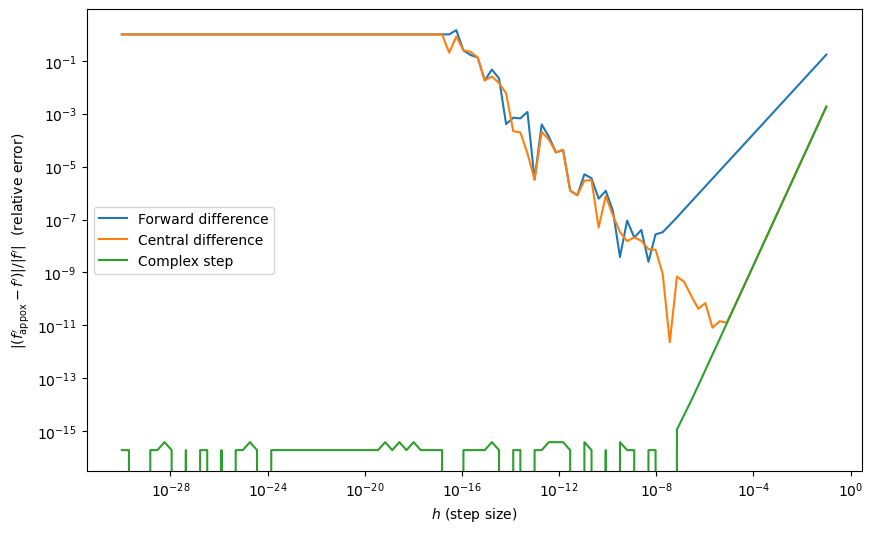

In [6]:
import numpy as np

def f(x):
    return (x - 3)*x**3*(x - 6)**4*np.sqrt(x)

x0 = 0.5

npts = 100
dh = 10**np.linspace(-1, -30, npts)

fd = np.zeros(npts)
cd = np.zeros(npts)
cs = np.zeros(npts)
for i, h in enumerate(dh):
    fd[i] = (f(x0 + h) - f(x0))/h
    cd[i] = 0.5*(f(x0 + h) - f(x0 - h))/h
    cs[i] = f(x0 + 1j*h).imag/h

# Cheat and use the complex step as the 'exact' answer
h = 1e-50
ans = f(x0 + 1j*h).imag/h

plt.figure(figsize=(10, 6))
plt.loglog(dh, np.abs((fd - ans)/ans), label='Forward difference')
plt.loglog(dh, np.abs((cd - ans)/ans), label='Central difference')
plt.loglog(dh, np.abs((cs - ans)/ans), label='Complex step')
plt.xlabel(r"$h$ (step size)")
plt.ylabel(r"$|(f_{\text{appox}}' - f')|/|f'|$  (relative error)")
plt.legend()
plt.show()

## The Adjoint Method

The adjoint method is a technique to compute the total derivative or gradient of a function of interest when using a reduced-space method. The adjoint method takes into account the direct dependence of the function on the design variables, and the indirect dependence of the function through the state variables that in turn are obtained by solving the governing equations.

We will look at two ways to derive the adjoint. Both derivations provide different perspectives and are both used in the literature.

To help understand and motivate the adjoint method, we'll look at a simple 3-bar truss system.

### A simple example

<!-- \begin{tikzpicture}
\draw[fill=black] (1.9, 0) -- (2.1, 0) -- (2.1, -0.1) -- (1.9, -0.1) -- cycle;
\draw[fill=black] (0, 1.9) -- (0, 2.1) -- (-0.1, 2.1) -- (-0.1, 1.9) -- cycle;
\draw[fill=black] (0, 0.1) -- (0.1, 0) -- (0, -0.1) -- (-0.1, 0) -- cycle;
\draw[thick] (0, 2) -- node[midway, above] {$A_{1}$} (2, 2);
\draw[thick] (0, 0) -- node[midway, above left] {$A_{2}$} (2, 2);
\draw[thick] (2, 0) -- node[midway, right] {$A_{3}$} (2, 2);
\draw[thick, |-|] (0, -.5) -- node[midway, below] {L} (2, -.5);
\draw[thick, |-|] (-.5, 0) -- node[midway, left] {L} (-.5, 2);
\draw[thick, ->] (2, 2) -- (3.5, 2) node[below] {$F_{1}$};
\draw[thick, ->] (2, 2) -- (2, 3.5) node[right] {$F_{2}$};
\draw[fill=white] (2, 2) circle (0.05) node[above right] {1};
\end{tikzpicture} -->

* The design variables are $x = \left[ x_1,\; x_2,\; x_3 \right]$
* The state variables $u = \left[ u_1,\; u_2 \right]$
* The governing equations are:

\begin{equation*}
R(x, u) = 
\frac{E}{2\sqrt{2}L} 
\begin{bmatrix}
2\sqrt{2} x_1 + x_2 & x_{2} \\
x_{2} & x_{2} + 2\sqrt{2} x_3 \\
\end{bmatrix}
\begin{bmatrix}
u_1 \\
u_2 \end{bmatrix} -
\begin{bmatrix}
F_1 \\
F_2 \end{bmatrix}
=
\begin{bmatrix}
0 \\
0
\end{bmatrix}
\end{equation*}

Minimize the displacement:

\begin{equation*}
f(x, u) = u_1^2 + u_2^2
\end{equation*}

Subject to stress constraints in the bars:

\begin{equation*}
c(x, u) = 
\begin{bmatrix}
1 \\ 1 \\ 1
\end{bmatrix} 
- \frac{E}{\sqrt{2}L \sigma_{\max}} 
\begin{bmatrix}
\sqrt{2} u_1 \\
u_1 + u_2 \\
\sqrt{2} u_2 \\
\end{bmatrix} \ge 0
\end{equation*}

* Note that the design variables do not appear here at all
* However, $u_1$ and $u_2$ are functions of $x$ if we use the governing equations
 
\begin{equation*}
\begin{bmatrix}
u_{1} \\
u_2
\end{bmatrix} = \frac{1}{E} 
\frac{2\sqrt{2}L}{x_2^2 + 2\sqrt{2} x_{2}(x_1 + x_3) + 8x_1 x_3}
\begin{bmatrix}
(x_{2} + 2\sqrt{2} x_3)F_{1} - x_{2} F_{2} \\
(2\sqrt{2} x_1 + x_2) F_{2} - x_{2} F_{1}
\end{bmatrix}
\end{equation*}

* The expressions are complicated, even for this simple example

### Deriving the Adjoint Method using the Lagrangian

Consider the optimization problem with just the objective and the
governing equations:

\begin{equation*}
\begin{aligned}
\text{minimize} \qquad & f(x, u) \\
\text{w.r.t.} \qquad & x, u \\
\text{governed by} \qquad & R(x, u) = 0
\end{aligned}
\end{equation*}

We can treat this problem as an equality-constrained minimization problem
The Lagrangian for this function is:

\begin{equation*}
\mathcal{L} = f(x, u) + \psi^{T} R(x, u)
\end{equation*}

* $\psi$ are the Lagrange multipliers, but in this context they are called the *adjoint variables*
* We can treat the combination of $(x, u)$ as optimization variables

We can now write the K.K.T. conditions for the equality-constrained optimization problem as follows:

\begin{equation*}
\begin{aligned}
\frac{\partial \mathcal{L}}{\partial x} & \implies & \frac{\partial f}{\partial x} + \psi^{T} \frac{\partial R}{\partial x} = 0 \\
\frac{\partial \mathcal{L}}{\partial u} & \implies & \frac{\partial f}{\partial u} + \psi^{T} \frac{\partial R}{\partial u} = 0 \\
\end{aligned}
\end{equation*}

Taking the second equation, we can rearrange as follows: 

\begin{equation*}
\frac{\partial R}{\partial u}^{T} \psi = -\frac{\partial f}{\partial u}^{T} 
\end{equation*}

* This equation is known as the adjoint equation
* It depends on the partial derivatives with respect to $u$
* The formulation of the design variables does not affect the values of $\psi$

If we solve the adjoint equation, we will get $\psi$. Next we can compute the gradient as follows:

\begin{equation*}
\nabla f = \frac{\partial \mathcal{L}}{\partial x} 
= \frac{\partial f}{\partial x} + \psi^{T} \frac{\partial R}{\partial x}
\end{equation*}

#### Back to our example

The adjoint equation is:

\begin{equation*}
\frac{\partial R}{\partial u}^{T} \psi = - \frac{\partial f}{\partial u}^{T} 
\end{equation*}

* Take $f(x, u) = u_1^2 + v_1^2$
* In our example $\partial R/\partial u = \left[\partial R/\partial u\right]^{T}$ (self-adjoint/symmetric):
 
\begin{equation*}
\frac{E}{2\sqrt{2}L} \begin{bmatrix}
2\sqrt{2} x_1 + x_2 & x_{2} \\
x_{2} & x_{2} + 2\sqrt{2} x_3 \\
\end{bmatrix}
\begin{bmatrix}
\psi_1 \\
\psi_2 \end{bmatrix} = 
- \begin{bmatrix}
2u_1 \\
2u_2
\end{bmatrix}
\end{equation*}

* Recall $\partial f/\partial x = 0$

$$
\nabla f = \frac{\partial f}{\partial x} + \psi^{T} \frac{\partial R}{\partial x} = 
\begin{bmatrix} \psi_1 & \psi_2 \end{bmatrix}
\frac{E}{2\sqrt{2}L} \begin{bmatrix}
2\sqrt{2} u_1 & u_1 + u_2 &  0 \\
0             & u_1 + u_2 &  2\sqrt{2} u_2 \\
\end{bmatrix}
$$

* Try the constraints for yourself!

### Some implementation details

\begin{equation*}
\begin{aligned}
\frac{\partial R}{\partial u}^{T} \psi & = -\frac{\partial f}{\partial u}^{T} \\
\nabla f & = \frac{\partial f}{\partial x} + \psi^{T} \frac{\partial R}{\partial x}
\end{aligned}
\end{equation*}

* When $R(x, u) = 0$ is large, solving the adjoint equation is the most expensive single operation in computing the derivative
* Often iterative methods are used for very large systems
* The adjoint equation must be driven to a tight tolerance to obtain accurate gradients
* Codes that use Newton's method may compute $\partial R/\partial u$ already (or an approximation)
* ${\partial R}/{\partial u}^{T}$ and $\psi^{T} {\partial R}/{\partial x}$ terms can be reused for multiple functions
* Note that we don't need to compute and store ${\partial R}/{\partial x}$, instead we only need matrix-vector products with $\psi^{T} {\partial R}/{\partial x}$. These may be faster and less memory-intensive.

### A second look at the adjoint method

We can also derive the adjoint by distinguishing between partial and *total* derivatives.
Partial derivatives compute the derivative of the explicit dependence of a function or expression

* Denote partial derivatives as $\partial f/\partial x$
* Total derivatives include the implicit dependence of the expression or variable
* Denote total derivatives as $\mathrm{d} f/\mathrm{d} x$
 
Recall that we wrote $f(x, u(x))$ and $R(x, u(x)) = 0$ 

Take the total derivative of $f$ and $R$:

\begin{equation*}
\begin{aligned}
\frac{\mathrm{d} f}{\mathrm{d} x} & = \frac{\partial f}{\partial x} + \frac{\partial f}{\partial u}\frac{\mathrm{d} u}{\mathrm{d} x} \\
\frac{\mathrm{d} R}{\mathrm{d} x} & = \frac{\partial R}{\partial x} + \frac{\partial R}{\partial u}\frac{\mathrm{d} u}{\mathrm{d} x} = 0 \\
\end{aligned}
\end{equation*}

## The Adjoint and Direct Methods

Rearranging the second equation, we get the following:

\begin{equation*}
\frac{\mathrm{d} u}{\mathrm{d} x} = - \left[\frac{\partial R}{\partial u}\right]^{-1} \frac{\partial R}{\partial x}
\end{equation*}

This expression for the total derivative of the design variables can then be substituted back into the total derivative of the function $f(x, u)$:

\begin{equation*}
\frac{\mathrm{d} f}{\mathrm{d} x} = \frac{\partial f}{\partial x} {\underbrace{- \frac{\partial f}{\partial u}\left[\frac{\partial R}{\partial u}\right]^{-1}}_{-\psi^{T}}} \frac{\partial R}{\partial x} 
\end{equation*}

* The adjoint method is obtained by substituting $\psi$ as follows:

\begin{equation*}
\psi = - \frac{\partial f}{\partial u}\left[\frac{\partial R}{\partial u}\right]^{-1}
\end{equation*}

This leads to the equation:

\begin{equation*}
\left[\frac{\partial R}{\partial u}\right]^{T} \psi = - \frac{\partial f}{\partial u}^{T}
\end{equation*}

\begin{equation*}
\frac{\mathrm{d} f}{\mathrm{d} x} = \frac{\partial f}{\partial x} - \frac{\partial f}{\partial u}\underbrace{\left[\frac{\partial R}{\partial u}\right]^{-1} \frac{\partial R}{\partial x}}_{-\phi}
\end{equation*}

The direct method is obtained by substituting $\phi$ as follows:
\begin{equation*}
\phi = - \left[\frac{\partial R}{\partial u}\right]^{-1}\frac{\partial R}{\partial x}
\end{equation*}

Then the total derivative can be computed as follows:

\begin{equation*}
\frac{\mathrm{d} f}{\mathrm{d} x} = \frac{\partial f}{\partial x} + \frac{\partial f}{\partial u}\phi
\end{equation*}

### Direct vs. adjoint methods

* The adjoint method requires one linear system solve for each gradient evaluation and scales well with increasing numbers of design variables

* The direct method requires a linear system solve for each design variable, but $\phi = {\mathrm{d} u}/{\mathrm{d} x}$ may be reused for multiple functions
  
* The adjoint method is generally the best for problems with a large number of design variables and a small number of constraints

* The direct method is generally the best for problems with a large number of constraints and a small number of design variables
 
* Neither method works well for both large numbers of  constraints and design variables


### The direct method for our example problem

First solve:

\begin{equation*}
\begin{bmatrix}
2\sqrt{2} x_1 + x_2 & x_{2} \\
x_{2} & x_{2} + 2\sqrt{2} x_3 \\
\end{bmatrix}
\begin{bmatrix}
\phi_{11} & \phi_{12} & \phi_{13} \\ 
\phi_{21} & \phi_{22} & \phi_{23}
\end{bmatrix} =
-\begin{bmatrix}
2\sqrt{2} u_1 & u_1 + u_2 &  0 \\
0             & u_1 + u_2 &  2\sqrt{2} u_2 \\
\end{bmatrix}
\end{equation*}

* Note that we solve 3 equations to obtain the total derivative

Then compute the total derivative:

$$
\frac{\mathrm{d} f}{\mathrm{d} x} = 
\begin{bmatrix} 2u_1 & 2u_2 \end{bmatrix}
\begin{bmatrix}
\phi_{11} & \phi_{12} & \phi_{13} \\ 
\phi_{21} & \phi_{22} & \phi_{23}
\end{bmatrix}
$$

## Implementation of the Adjoint Method

In this section, we derive the adjoint method for the aerodynamic analysis presented above.
The key steps in the derivation are identifying all the necessary terms in the adjoint and verifying the implementation through a complex-step derivative evaluation.

In the aerodynamic optimization example above, the residual is given as

$$
R(x, u) \equiv
\begin{bmatrix} a_{11} & a_{12} & \ldots & a_{1N} \\ a_{21} & a_{22} & \ldots & a_{2N} \\ \vdots & \vdots & \ddots & \vdots \\ a_{N1} & a_{N2} & \ldots & a_{NN} \end{bmatrix} \begin{bmatrix} u_{1} \\ u_{2} \\ \vdots \\ u_{N} \end{bmatrix} - \begin{bmatrix} b_{1} \\ b_{2} \\ \vdots \\ b_{N} \end{bmatrix}
$$

where here $u = (u_{1}, u_{2}, \ldots, u_{N})$. Note that there are $N$ unknowns and the coefficients $b_{m}(x) = \frac{c(\theta_{m})}{4b} c_{l,\alpha} (\alpha_{\infty} + x_{m})$ depend on the design variables. 

The terms required for the adjoint equation can be split as follows:

1. The derivative $\partial R/\partial u$
2. The derivative $\partial f/\partial u$ 

To evaluate the total derivative, we additionally require:

3. The derivative $\partial R/\partial x$
4. The derivative $\partial f/\partial x$

First tackling the derivatives with respect to the residual:

$$
\frac{\partial R}{\partial u} = 
\begin{bmatrix} a_{11} & a_{12} & \ldots & a_{1N} \\ a_{21} & a_{22} & \ldots & a_{2N} \\ \vdots & \vdots & \ddots & \vdots \\ a_{N1} & a_{N2} & \ldots & a_{NN} \end{bmatrix} 
$$

$$
\frac{\partial R}{\partial x} = 
- \frac{c_{l,\alpha}}{4b}
\begin{bmatrix} 
c(\theta_{1})\sin(\theta_{1}) & 0 & \ldots & 0\\
0 & c(\theta_{2})\sin(\theta_{2}) & \ldots & 0\\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \ldots & c(\theta_{N})\sin(\theta_{N}) \\
\end{bmatrix} 
$$

The remaining derivatives depend on the selected function of interest.
The coefficient of drag is expressed as:

\begin{equation*}
C_{D} = \pi AR \sum_{n=1}^{N} n u_{n}^2
\end{equation*}

The required derivatives are $\partial C_{D}/\partial x = 0$ and

$$
\frac{\partial C_{D}}{\partial u} = 
2 \pi AR
\begin{bmatrix}
u_{1} &
2 u_{2} &
3 u_{3} &
\ldots &
N u_{N} 
\end{bmatrix}
$$

The coefficient of lift is

\begin{equation*}
C_{L} = \pi AR u_{1}
\end{equation*}

The required derivatives are $\partial C_{L}/\partial x = 0$ and

$$
\frac{\partial C_{L}}{\partial u} = 
\pi AR
\begin{bmatrix}
1 &
0 &
\ldots &
0
\end{bmatrix}
$$

The bending moment coefficient is

\begin{equation*}
C_{b} = AR \sum_{n=1}^{N} c_{n} u_{n}
\end{equation*}

The required derivatives are $\partial C_{b}/\partial x = 0$ and

$$
\frac{\partial C_{b}}{\partial u} = 
AR
\begin{bmatrix}
c_{1} &
c_{2} &
\ldots &
c_{n}
\end{bmatrix}
$$

dCDdx:     7.5381359107e-01  CS:     7.5381359107e-01  Rel. Error:     5.8912337892e-16
dCLdx:     2.4979317242e+00  CS:     2.4979317242e+00  Rel. Error:     3.5556553091e-16
dCbdx:    -6.0439003853e-01  CS:    -6.0439003853e-01  Rel. Error:     5.5107941256e-16
message:        Optimization terminated successfully
function evals: 18
iterations:     18
message:        Optimization terminated successfully
function evals: 15
iterations:     15


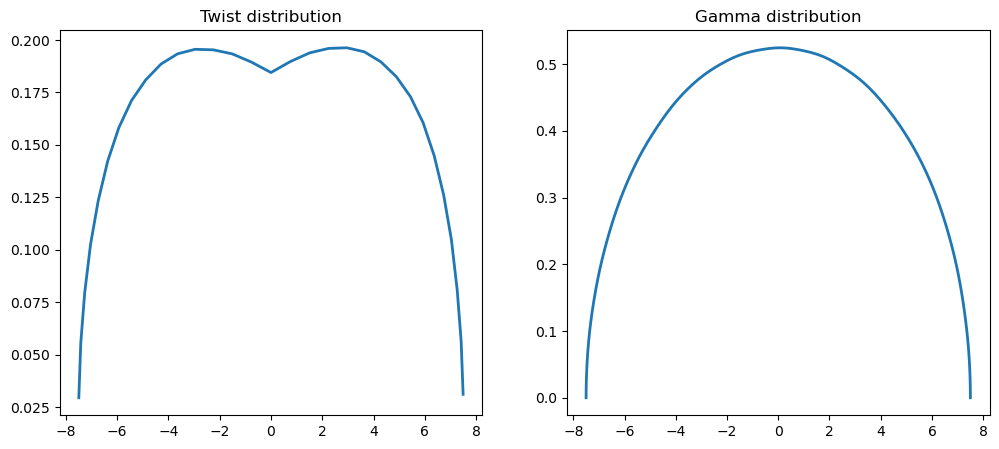

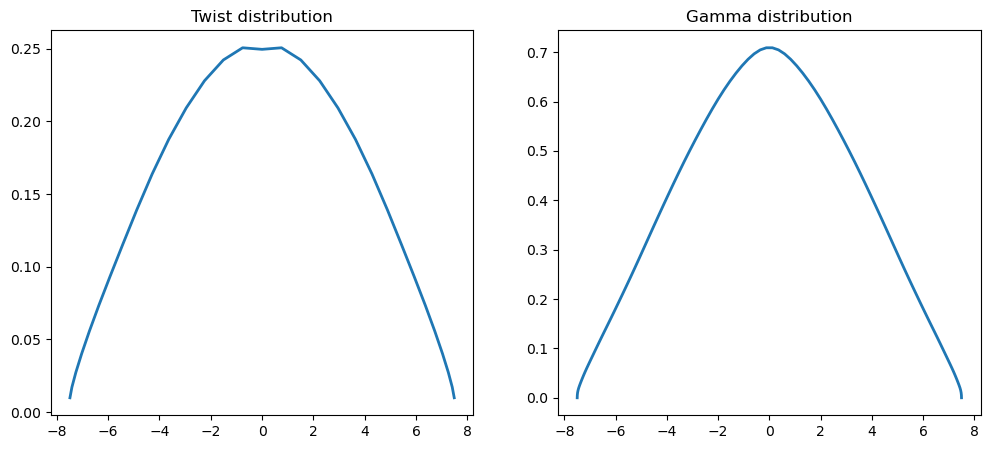

In [2]:
# Run the initial design problem: Minimize induced drag subject to a lift
# constraint.
np.random.seed(0)
x = np.random.uniform(size=N)
p = np.random.uniform(size=N)

# Complex-step derivative step length
h = 1e-30

# Test the derivative of drag against CS
dCDdx = lifting_line.compute_drag_gradient(x)
adjoint_result = np.dot(dCDdx, p)
cs_result = lifting_line.compute_drag(x + h*1j*p).imag/h
print('dCDdx: %20.10e  CS: %20.10e  Rel. Error: %20.10e'%(
    adjoint_result, cs_result, np.abs((adjoint_result - cs_result)/cs_result)))

# Test the derivative of lift against CS
dCLdx = lifting_line.compute_lift_gradient(x)
adjoint_result = np.dot(dCLdx, p)
cs_result = lifting_line.compute_lift_constraint(x + h*1j*p).imag/h
print('dCLdx: %20.10e  CS: %20.10e  Rel. Error: %20.10e'%(
    adjoint_result, cs_result, np.abs((adjoint_result - cs_result)/cs_result)))

# Test the derivative of the moment against CS
dCbdx = lifting_line.compute_moment_gradient(x)
adjoint_result = np.dot(dCbdx, p)
cs_result = lifting_line.compute_moment_constraint(x + h*1j*p).imag/h
print('dCbdx: %20.10e  CS: %20.10e  Rel. Error: %20.10e'%(
    adjoint_result, cs_result, np.abs((adjoint_result - cs_result)/cs_result)))

# Optimize the lift-constrained drag minimization
res = minimize(lifting_line.compute_drag, x,
               jac=lifting_line.compute_drag_gradient,
               method='SLSQP',
               constraints={'type': 'eq',
                            'fun': lifting_line.compute_lift_constraint,
                            'jac': lifting_line.compute_lift_gradient})
lifting_line.plot_result(res.x)

print(f"message:        {res.message}")
print(f"function evals: {res.nfev}")
print(f"iterations:     {res.nit}")

# Run the modified problem: Minimize induced drag subject to a lift
# constraint and a requirement that the root bending moment be bounded
# by the target bending moment coefficient.
x = np.ones(N)
res = minimize(lifting_line.compute_drag, x, method='SLSQP',
               jac=lifting_line.compute_drag_gradient,
               constraints=[{'type': 'eq', 
                             'fun': lifting_line.compute_lift_constraint,
                             'jac': lifting_line.compute_lift_gradient},
                            {'type': 'ineq',
                             'fun': lifting_line.compute_moment_constraint,
                             'jac': lifting_line.compute_moment_gradient}])
lifting_line.plot_result(res.x)

print(f"message:        {res.message}")
print(f"function evals: {res.nfev}")
print(f"iterations:     {res.nit}")

plt.show()

## Automatic differentiation

Automatic differentiation (AD) is a tool for generating the derivatives of a function of interest efficiently via modification of the source code.

* Here the *modification* can be very subtle, as in operator overloading methods, leading to code that has the appearance of being the same, but executes additional instructions that account for the gradient

The way AD methods work is through a systematic implementation of the chain rule. These methods have been developed and implemented by computer scientists and make extensive use of graph theory.

The important thing to note about AD is that there are two modes of differentiation:

1. Forward mode (or tangent mode): In this mode the derivatives are computed in the same order as the original code. Think of this as multiplying from right-to-left in the chain rule.
2. Reverse mode (or adjoint mode): In this mode the code is first evaluated in the normal sequence, then the derivative is computed by running through the operations in reverse order. Think of this as multiplying from left-to-right in the chain rule.

* If your function has a few inputs and many outputs, then forward mode is best
* If your function has a few outputs and many inputs, then reverse mode is best

### Notation

In AD notation, forward mode derivatives are written with an over dot. You can think of this as a derivative with respect to a scalar parameter $t$

\begin{equation*}
\dot{x} = \dfrac{\partial x}{\partial t}.
\end{equation*}

These forward derivative notation is applied regarless of the dimensions of $x$, which may be a scalar, vector or matrix.

Reverse mode derivatives are written with an over bar. These derivatives represent the derivative of the output with respect to the bar variable

\begin{equation*}
\bar{x} = \dfrac{\partial f}{\partial x}
\end{equation*}

Note that both the forward derivative and reverse mode derivative variables require the same size storage in memory as the original variable. AD libraries utilize storage for both the value and its derivative.

Setting the forward or reverse mode derivatives at a step within your code prior to the evaluation of the derivatives is called *seeding* the variable values.

### Example

Consider the function $y(x_1, x_2)$ that takes the scalar inputs $x_1$ and $x_2$

\begin{equation*}
y = \sin(x_1) + x_2 \cos(x_2)
\end{equation*}

In an computer program, this computation would be performed by breaking up this expression into a sequence of unary and binary operations. A unary operation takes a single argument and returns a value, while a binary operation takes two arguments and returns a single value. In this case, a sequence of operations might be

* Operation 1: $t_1 = \sin(x_1)$
* Operation 2: $t_2 = \cos(x_2)$
* Operation 3: $t_3 = x_{2} t_{2}$
* Operation 4: $y = t_{1} + t_3$

Note that steps 1 and 2 involve unary operations while steps 3 and 4 are binary operations.

A visualization of the graph structure of this computation is shown below

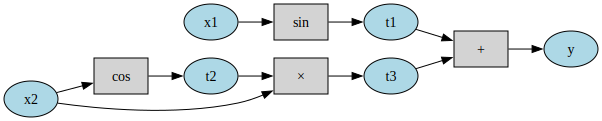

In [2]:
from graphviz import Digraph

g = Digraph()
g.attr(rankdir="LR")

# Variable nodes
g.attr("node", shape="ellipse", style="filled", fillcolor="lightblue")
g.node("x1")
g.node("x2")
g.node("t1")
g.node("t2")
g.node("t3")
g.node("y")

# Operation nodes
g.attr("node", shape="box", style="filled", fillcolor="lightgray")
g.node("sin", "sin")
g.node("cos", "cos")
g.node("mul", "×")
g.node("add", "+")

# Edges
g.edge("x1", "sin")
g.edge("sin", "t1")

g.edge("x2", "cos")
g.edge("cos", "t2")

g.edge("x2", "mul")
g.edge("t2", "mul")
g.edge("mul", "t3")

g.edge("t1", "add")
g.edge("t3", "add")
g.edge("add", "y")

g



Forward mode differentation consists of propagating the derivatives of the inputs through to the output. The sequence of steps for the forward mode derivative follow the same sequence as the original code.
For this simple example, the inputs to the forward mode would be $x_{1}$, $x_{2}$ as well as the derivative inputs $\dot{x}_1$ and $\dot{x}_{2}$. In automatic differentation, the values $\dot{x}_1$ and $\dot{x}_{2}$ are called seeds.

* Operation 1: $\dot{t}_1 = \cos(x_1) \dot{x}_1$
* Operation 2: $\dot{t}_2 = -\sin(x_2) \dot{x}_2$
* Operation 3: $\dot{t}_3 = \dot{x}_{2} t_{2} + x_{2} \dot{t}_{2}$
* Operation 4: $\dot{y} = \dot{t}_{1} + \dot{t}_3$

To obtain the partial derivative $\partial y/\partial x_1$, you would set the seeds $\dot{x}_{1} = 1$, and $\dot{x}_{2} = 0$, and to obtain the partial derivative $\partial y/\partial x_2$, you would set the seeds $\dot{x}_{1} = 0$, and $\dot{x}_{2} = 1$, 

Reverse mode differentation reverses the sequence of operations compared to the original sequence. Once the original computation has completed, the reverse code is executed.
In reverse mode, a seed is set on the output, $\bar{y} = 1$, and propagated backwards to the input. 
Reverse mode is implemented by recording the forward sequence of operations on a tape or stack and then reversing these operations during the execution of the reverse mode.
For this simple example, this sequence of steps would consist of the following

* Operation 4: $\bar{t}_{1} = \bar{y}$, $\bar{t}_{3} = \bar{y}$
* Operation 3: $\bar{x}_2 = t_{2} \bar{t}_{3}$, $\bar{t}_2 = x_2 \bar{t}_3$
* Operation 2: $\bar{x}_1 = \cos(x_1) \bar{t}_{1}$
* Operation 1: $\bar{x}_2 = \bar{x}_2 - \sin(x_2) \bar{t}_{2}$

Here $\bar{x}_{1} = \partial y/\partial x_1$ and $\bar{x}_{2} = \partial y/\partial x_2$.

### Deriving automatic-differentation formula

Deriving forward mode derivative expressions is straightforward using standard differentiation rules. For instance, the forward mode derivative expression for the operation $c = a \cos(b)$, is

\begin{equation*}
\dot{c} = \dot{a} \cos(b) - a \sin(b) \dot{b}
\end{equation*}

However, reverse mode derivative expressions are more challenging to derive. This section presents a techniques to obtain reverse mode derivative expressions.

Consider a function that computes the scalar output value $f$ based on the scalar inputs $a$ and $b$. Furthermore, suppose that this computation requires an intermediate evaluation of a value $c$. This could be written as:

\begin{equation*}
f = F(C(a, b))
\end{equation*}

In practice, to implement this function in a computer program, you would compute $c = C(a, b)$, then compute $f = F(c)$. Thus, $c$ would be an intermediate variable in the computation.

Given the input forward derivatives $\dot{a}$ and $\dot{b}$, the forward derivative of $c$ can be found using

\begin{equation*}
\dot{c} = \dfrac{\partial C}{\partial a} \dot{a} + \dfrac{\partial C}{\partial b} \dot{b}  
\end{equation*}

This formula is straightforward to derive. Now the derivative of $F$ can be computed as

\begin{equation*}
\dot{f} = \dfrac{\partial F}{\partial c} \dot{c}
\end{equation*}

Reverse-mode derivatives start with the reverse mode derivative of the input variable $\bar{c} = \partial F/\partial c$.

Now, we can use the identity

\begin{equation*}
\dfrac{\partial F}{\partial c} \dot{c} = \bar{c} \dot{c} = \dfrac{\partial F}{\partial a} \dot{a} + \dfrac{\partial F}{\partial b} \dot{b} = \bar{a} \dot{a} + \bar{b} \dot{b}
\end{equation*}

to derive formula for $\bar{a}$ and $\bar{b}$ in terms of $\bar{c}$ and the partial derivatives.
In this case

\begin{equation*}
\bar{c} \dot{c} = \bar{c}\left( \dfrac{\partial C}{\partial a} \dot{a} + \dfrac{\partial C}{\partial b} \dot{b} \right) = \bar{c} \dfrac{\partial C}{\partial a} \dot{a} + \bar{c} \dfrac{\partial C}{\partial b} \dot{b}
\end{equation*}

As a result, we can easily identify that 

\begin{equation*}
\bar{a} = \bar{c} \dfrac{\partial C}{\partial a} \qquad \qquad \bar{b} = \bar{c} \dfrac{\partial C}{\partial b}
\end{equation*}

The key identity that we used to derive the reverse mode derivatives was the chain rule relationship

\begin{equation*}
\bar{c} \dot{c} = \bar{a} \dot{a} + \bar{b} \dot{b}
\end{equation*}

which is a concise statement of the chain rule. If the function requires takes more than two inputs, they can be added to the right-hand-side of this formula, and if the function produces more outputs, they can be added to the left-hand-side of the formula.

Applying the approach above, gives the following

\begin{equation*}
\bar{c} \dot{c} = \bar{c}( \dot{a} \cos(b) - a \sin(b) \dot{b}) = \bar{c} \cos(b) \dot{a} - \bar{c} a \sin(b) \dot{b} = \bar{a} \dot{a} + \bar{b} \dot{b}
\end{equation*}

where we can isolate the reverse mode derivative expressions

\begin{aligned}
\bar{a} &= \bar{c} \cos(b) \\
\bar{b} &= - \bar{c} a \sin(b)\\
\end{aligned}

The reverse mode derivatives can be extended for more general expressions that involve additional inputs and outputs by adding terms to the left and right-hand sides of the chain rule relationship.

#### Matrix expressions

This approach can be extended to work with matrix expressions that are used in many computer algorithms.
In this context, consider the matrices $A, B, C \in \mathbb{R}^{n \times n}$ used to obtain the scalar output $f$.

Given the matrix expression $C$ as a function of $A$ and $B$, the following relationship will hold

\begin{equation*}
\sum_{i=1}^{n} \sum_{j=1}^{n} \bar{C}_{ij} \dot{C}_{ij} = \sum_{i=1}^{n} \sum_{j=1}^{n} \bar{A}_{ij} \dot{A}_{ij} + \sum_{i=1}^{n} \sum_{j=1}^{n} \bar{B}_{ij} \dot{B}_{ij}
\end{equation*}

This equation can be re-written in terms of the trace operator to avoid the use of index notation

\begin{equation*}
\text{tr}(\bar{C}^{T} \dot{C}) = \text{tr}(\bar{A}^{T} \dot{A}) + \text{tr}(\bar{B}^{T} \dot{B})
\end{equation*}

Note that it can be helpful to use the properties of the trace operation such that $\text{tr}(AB) = \text{tr}(BA) = \text{tr}(B^{T} A^{T}) = \text{tr}(A^{T}B^{T})$.


#### Examples

Consider the matrix expression $C = A B$. Then the forward derivative is

\begin{equation*}
\dot{C} = \dot{A} B + A \dot{B}
\end{equation*}

Applying the formula above gives

\begin{equation*}
\text{tr}(\bar{C}^{T} \dot{C}) = \text{tr}(\bar{C}^{T} (\dot{A} B + A \dot{B})) = 
\text{tr}(\bar{C}^{T}\dot{A} B) + \text{tr}(\bar{C}^{T} A \dot{B}) = \text{tr}(B \bar{C}^{T}\dot{A}) + \text{tr}(\bar{C}^{T} A \dot{B})
\end{equation*}

Based on this relationship $\bar{A}^{T} = B \bar{C}^{T}$ and $\bar{B}^{T} = \bar{C}^{T} A$. As a result

\begin{equation*}
\bar{A} = \bar{C} B^{T} \qquad \qquad \bar{B} = A^{T} \bar{C}
\end{equation*}


Consider the matrix expression $C = A^{-1}$ where $A$ is square and invertible. The forward mode derivative can be derived by taking the derivative of the expression $A C = 1$.

\begin{equation*}
\dot{A} C + A \dot{C} = 0 
\end{equation*}

Rearranging gives

\begin{equation*}
\dot{C} = - A^{-1} \dot{A} A^{-1}
\end{equation*}

Using the trace identity gives

\begin{equation*}
\text{tr}(\bar{C}^{T} \dot{C}) = -\text{tr}(\bar{C}^{T} A^{-1} \dot{A} A^{-1}) = -\text{tr}(A^{-1} \bar{C}^{T} A^{-1} \dot{A})
\end{equation*}

As a result, we can identify that $\bar{A}^{T} = - A^{-1} \bar{C}^{T} A^{-1}$ or 

\begin{equation*}
\bar{A} = -A^{-T} \bar{C} A^{-T}
\end{equation*}


#### Exercises

Show that the matrix-matrix product ${C} = {A} {B}^{T}$

* Forward: $\dot{{C}} = \dot{{A}} {B}^{T} + {A} \dot{{B}}^{T}$
* Reverse: $\bar{{A}} = \bar{{C}} {B}$, $\bar{{B}} = \bar{{C}}^{T} {A}$

Lagrange-Green strain ${E} = \frac{1}{2} \left( {U} + {U}^{T} + {U}^{T} {U} \right)$

* Forward $\dot{{E}} = \frac{1}{2} \left( \dot{{U}} + \dot{{U}}^{T} + \dot{{U}}^{T} {U} + {U}^{T} \dot{{U}} \right)$
* Reverse $\bar{{U}} = ({I} + {U}) \bar{{E}}$

## AD in practice: Autograd

In this example, we'll demonstrate how to use automatic differentiation tools in python.

https://github.com/HIPS/autograd

Autograd uses an operator overloading approach. To use autograd, you first have to use a trick to import it as the numpy package.

Autograd can't handle all operations! 

From https://github.com/HIPS/autograd/blob/master/docs/tutorial.md

What it can support:

* Most `numpy` functions and `numpy.ndarray` methods
* Indexing and slicing of arrays, e.g. `x = A[3, :, 2:4]`
* Explicit array creation from lists `A = np.array([x, y])`

What it cannot support:

* Assignment to arrays `A[0,0] = x`
* Implicit casting of lists to arrays `A = np.sum([x, y])`, use `A = np.sum(np.array([x, y]))` instead.
* `A.dot(B)` notation (use `np.dot(A, B)` instead)
* In-place operations (such as `a += b`, use `a = a + b` instead)
* Some isinstance checks, like `isinstance(x, np.ndarray)` or `isinstance(x, tuple)`, without first doing `from autograd.builtins import isinstance, tuple`.


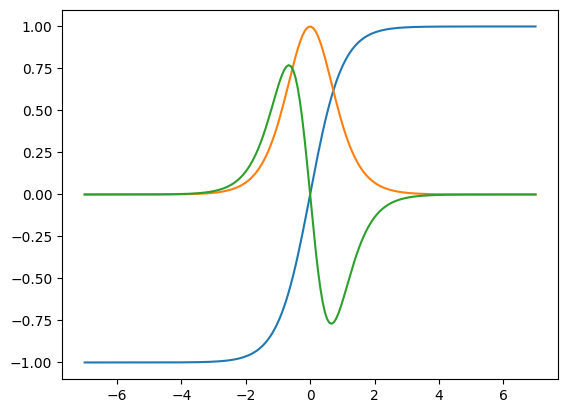

In [10]:
import autograd.numpy as np
from autograd import elementwise_grad as egrad  # for functions that vectorize over inputs
import matplotlib.pyplot as plt

def tanh(x):                 # Define a function
    y = np.exp(-2.0 * x)
    return (1.0 - y) / (1.0 + y)

x = np.linspace(-7, 7, 200)
plt.plot(x, tanh(x),
         x, egrad(tanh)(x),                                     # first  derivative
         x, egrad(egrad(tanh))(x))                              # second derivative
plt.show()

dfdx:    -1.6895786065e-02  CS:    -1.6895786065e-02  Rel. Error:     1.2320635235e-15


/usr/local/lib/python3.9/site-packages/scipy/optimize/optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


Optimization iterations:  250
Function evaluations:  252
Objective function value:  0.029767104979055343
Mass constraint value:  4.656612873077393e-10


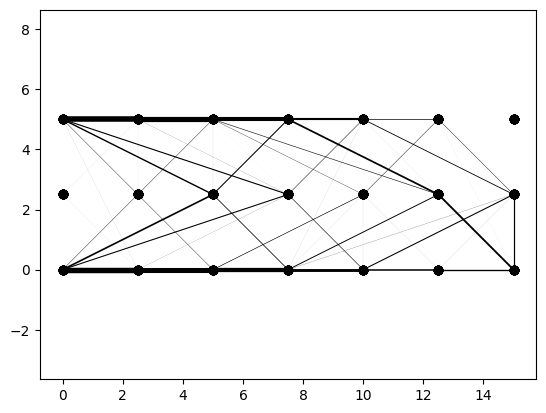

In [11]:
import autograd.numpy as np
from autograd import grad

from scipy.optimize import minimize

# Import parts of matplotlib for plotting
import matplotlib.pyplot as plt

# Import the greatest common divisor code
from math import gcd

class TrussAnalysis:
    def __init__(self, conn, xpos, loads, bcs, E, rho,
                 m_fixed, A_min, A_max):
        """
        Analysis problem for mass-constrained compliance minimization
        """

        # Store pointer to the data
        self.conn = conn
        self.xpos = np.array(xpos)
        self.loads = loads
        self.bcs = bcs

        # Set the material properties
        self.E = E
        self.rho = rho

        # Fixed mass value
        self.m_fixed = m_fixed

        # Set the values for the scaling
        self.A_min = A_min
        self.A_max = A_max
        
        # Allocate the matrices required
        self.nnodes = len(self.xpos)

        # Set the variable number array
        self.vars = np.ones((self.nnodes, 2), np.int32)
        
        # For each node that is in the boundary condition dictionary
        for node in self.bcs:
            for index in self.bcs[node]:
                self.vars[node, index] = -1

        # Set the variable numbers
        self.nvars = 0
        for node in range(self.nnodes):
            for index in range(2):
                if self.vars[node, index] >= 0:
                    self.vars[node, index] = self.nvars
                    self.nvars += 1

        # Create the load vector
        self.f = np.zeros(self.nvars)
        for node in self.loads:
            for index in range(2):
                if self.vars[node, index] >= 0:
                    self.f[self.vars[node, index]] += self.loads[node][index]

        return

    def compute_mass(self, x):
        """
        Evaluate the mass of the truss
        """

        # Compute the mass of the entire truss
        mass = 0.0
        for index, bar in enumerate(self.conn):
            # Get the first and second node numbers from the bar
            n1 = bar[0]
            n2 = bar[1]

            # Compute the nodal locations
            xd = self.xpos[n2, 0] - self.xpos[n1, 0]
            yd = self.xpos[n2, 1] - self.xpos[n1, 1]
            Le = np.sqrt(xd**2 + yd**2)
            mass += self.rho*Le*x[index]

        return mass - self.m_fixed

    def compute_compliance(self, x):
        """
        Evaluate the compliance of the truss
        """
        
        # Evaluate compliance objective
        K = self.assemble_mat(x)

        # Compute the displacement
        u = np.linalg.solve(K, self.f)

        # Compute the compliance objective
        return np.dot(u, self.f)

    def assemble_mat(self, x):
        """
        Given the connectivity, nodal locations and material properties,
        assemble the stiffness matrix

        input:
        A:   the bar areas

        output:
        K:   the stiffness matrix
        """

        # Zero the stiffness matrix
        K = np.zeros((self.nvars, self.nvars), dtype=x.dtype)

        # Loop over each element in the mesh
        for index, bar in enumerate(self.conn):
            # Get the first and second node numbers from the bar
            n1 = bar[0]
            n2 = bar[1]

            # Compute the nodal locations
            xd = self.xpos[n2, 0] - self.xpos[n1, 0]
            yd = self.xpos[n2, 1] - self.xpos[n1, 1]
            Le = np.sqrt(xd**2 + yd**2)
            C = xd/Le
            S = yd/Le
            
            r = np.zeros(self.nvars)
            if self.vars[n1, 0] >= 0:
                r[self.vars[n1, 0]] = C
            if self.vars[n1, 1] >= 0:
                r[self.vars[n1, 1]] = S
            if self.vars[n2, 0] >= 0:
                r[self.vars[n2, 0]] = -C
            if self.vars[n2, 1] >= 0:
                r[self.vars[n2, 1]] = -S
            
            # Compute the element stiffness matrix
            K = K + (self.E*x[index]/Le)*np.outer(r, r)
    
        return K

    def compute_forces(self, x):
        """
        Compute the forces in each of the truss members
        """
        
        # Evaluate compliance objective
        K = self.assemble_mat(x)

        # Compute the displacement
        u0 = np.linalg.solve(K, self.f)
        
        # Expand the solution to the full vector
        u = np.zeros(2*self.nnodes)
        for node in range(self.nnodes):
            for index in range(2):
                if self.vars[node, index] >= 0:
                    u[2*node + index] = u0[self.vars[node, index]]
        
        # Create the global stiffness matrix
        bar_forces = np.zeros(len(self.conn))

        # Loop over each element in the mesh
        for index, bar in enumerate(self.conn):
            # Get the first and second node numbers from the bar
            n1 = bar[0]
            n2 = bar[1]

            # Compute the nodal locations
            xd = self.xpos[n2, 0] - self.xpos[n1, 0]
            yd = self.xpos[n2, 1] - self.xpos[n1, 1]
            Le = np.sqrt(xd**2 + yd**2)
            C = xd/Le
            S = yd/Le

            # Compute the hat displacements
            u1_hat = C*u[2*n1] + S*u[2*n1+1]
            u2_hat = C*u[2*n2] + S*u[2*n2+1]

            # Compute the strain
            epsilon = (u2_hat - u1_hat)/Le

            # Compute the forces
            bar_forces[index] = self.E*x[index]*epsilon

        return bar_forces

    def plot_result(self, x):
        """
        Plot the deformed and undeformed truss structure
        """

        # Set the background colour
        fig = plt.figure(facecolor='w')

        for index, bar in enumerate(self.conn):
            n1 = bar[0]
            n2 = bar[1]
            plt.plot([self.xpos[n1, 0], self.xpos[n2, 0]],
                     [self.xpos[n1, 1], self.xpos[n2, 1]], '-ko',
                     linewidth=4*(x[index]/max(x)))

        plt.axis('equal')

        return

def get_ground_structure(N=4, M=4, L=2.5, P=10.0, n=5):
    """
    Set up the connectivity for a ground structure consisting of a 2D
    mesh of (N x M) nodes of completely connected elements.

    A single point load is applied at the lower right-hand-side of the
    mesh with a value of P. All nodes are evenly spaced at a distance
    L.

    input:
    N:  number of nodes in the x-direction
    M:  number of nodes in the y-direction
    L:  distance between nodes

    returns
    conn:   the connectivity
    xpos:   the nodal locations
    loads:  the loading conditions applied to the problem
    P:      the load applied to the mesh
    """

    # First, generate a co-prime grid that will be used to
    grid = []
    for x in range(1,n+1):
        for y in range(1,n+1):
            if gcd(x, y) == 1:
                grid.append((x, y))

    # Reflect the ge
    reflect = []
    for d in grid:
        reflect.append((-d[0], d[1]))

    grid.extend(reflect)
    grid.extend([(0,1), (1,0)])

    # Set up the connectivity array
    conn = []
    for i in range(N):
        for j in range(M):
            n1 = i + N*j
            for d in grid:
                if ((i + d[0] < N) and (j + d[1] < M) and
                    (i + d[0] >= 0) and (j + d[1] >= 0)):
                    n2 = i + d[0] + (j + d[1])*N
                    conn.append([n1, n2])

    # Set the positions of all the nodes
    xpos = []
    for j in range(M):
        for i in range(N):
            xpos.append([i*L, j*L])

    # Set the node locations
    loads = {}
    loads[N-1] = [0, -P]

    bcs = {}
    for j in range(M):
        bcs[j*N] = [0, 1]

    return conn, xpos, loads, bcs

def setup_ground_struct(N, M, L=2.5, E=70e9, rho=2700.0,
                        A_min=1e-4, A_max=10.0):
    """
    Create a ground structure with a given number of nodes and
    material properties.
    """

    # Create the ground structure
    conn, xpos, loads, bcs = get_ground_structure(N=N, M=M, L=L, P=10e3)

    # Set the fixed mass constraint
    m_fixed = 5.0*N*M*L*rho

    # Create the truss object
    truss = TrussAnalysis(conn, xpos, loads, bcs, E, rho, m_fixed,
                          A_min, A_max)

    return truss

# Create the truss optimization object
N = 7
M = 3
truss = setup_ground_struct(N, M, A_min=1e-6)

# Get the number of design variables and set the initial guess
n = len(truss.conn)
x = np.ones(n)

# Create the compliance gradient function
compliance_grad = grad(truss.compute_compliance)

# Set the step direction and complex step size
h = 1e-30
p = np.random.uniform(size=n)

# Test the ad derivative of compliance against CS
dfdx = compliance_grad(x)
ad_result = np.dot(dfdx, p)
cs_result = truss.compute_compliance(x + h*1j*p).imag/h
print('dfdx: %20.10e  CS: %20.10e  Rel. Error: %20.10e'%(
    ad_result, cs_result, np.abs((ad_result - cs_result)/ad_result)))

# Set the bounds for the design variables
bounds = [(truss.A_min, None)]*n

res = minimize(truss.compute_compliance,
               x, method='SLSQP', bounds=bounds,
               jac=compliance_grad,
               options={'maxiter': 250},
               constraints=[{'type': 'eq',
                             'fun': truss.compute_mass,
                             'jac': grad(truss.compute_mass)}])
truss.plot_result(res.x)
print('Optimization iterations: ', res.nit)
print('Function evaluations: ', res.nfev)
print('Objective function value: ', res.fun)
print('Mass constraint value: ', truss.compute_mass(res.x))

### Source code transformation

How does AD work for compiled codes?

There are several different AD tools for compiled languages.
These fall into two basic categories:

1. Operator overloading methods. Your scalar variables are replaced with overloaded type that keeps track of the value and gradient.

2. Source code transformation methods: They take your code as input and produce a differentiated version of the code.

Here we'll look at a `C` example that uses the AD tool Tapenade:

http://www-tapenade.inria.fr:8080/tapenade/index.jsp

This C++ function takes in two variables `x1` and `x2` and computes a return value:

```c
double func( double x1, double x2 ){
    double a1 = x1*x2 + sin(x1*x2)/sqrt(x1*x1 + x2*x2);
    double a2 = x1*x1*a1;
    return a1*a2 + a1;
}
```

#### Tangent mode

In tangent mode, the Tapende produces the following output:

```c
double func_d(double x1, double x1d, double x2, double x2d, double *func) {
    double a1;
    double a1d;
    double arg1;
    double arg1d;
    double result1;
    double result1d;
    double temp;
    arg1d = 2*x1*x1d + 2*x2*x2d;
    arg1 = x1*x1 + x2*x2;
    temp = sqrt(arg1);
    result1d = (arg1 == 0.0 ? 0.0 : arg1d/(2.0*temp));
    result1 = temp;
    temp = sin(x1*x2)/result1;
    a1d = x2*x1d + x1*x2d + (cos(x1*x2)*(x2*x1d+x1*x2d)-temp*result1d)/result1
    ;
    a1 = x1*x2 + temp;
    double a2 = x1*x1*a1;
    double a2d = a1*2*x1*x1d + x1*x1*a1d;
    *func = a1*a2 + a1;
    return (a2+1.0)*a1d + a1*a2d;
}
```

Note that the inputs `x1d` and `x2d` are the derivatives of the inputs `x1` and `x2`, respectively.


#### Reverse mode

In reverse mode, Tapenade produces the following output:

```c
void func_b(double x1, double *x1b, double x2, double *x2b, double funcb) {
    double a1 = x1*x2 + sin(x1*x2)/sqrt(x1*x1+x2*x2);
    double a1b = 0.0;
    double a2 = x1*x1*a1;
    double a2b = 0.0;
    double temp;
    double temp0;
    double tempb;
    double tempb0;
    double func;
    func = a1*a2 + a1;
    a2b = a1*funcb;
    a1b = (a2+1.0)*funcb + x1*x1*a2b;
    temp = x1*x1 + x2*x2;
    temp0 = sqrt(temp);
    tempb = cos(x1*x2)*a1b/temp0;
    tempb0 = (temp == 0.0 ? 0.0 : -(sin(x1*x2)*a1b/(2.0*pow(temp0, 3))));
    *x1b = 2*x1*a1*a2b + x2*a1b + 2*x1*tempb0 + x2*tempb;
    *x2b = x1*a1b + 2*x2*tempb0 + x1*tempb;
}
```

Note that the input is `funcb` and `x1b` and `x2b` are the outputs.
